# Backtesting VaR on the book

`backtesting.ipynb` tests the models on a single long SPY position. This notebook runs the same four 99% VaR models on the example book in `src/book.py`, a hedged portfolio of dollar positions in two desks:

- **equity_ls**: long $5m each of AAPL, MSFT, JPM and UNH, short $20m SPY. Roughly market neutral, so the risk is in the four stocks against the index.
- **rates_fx**: long $10m TLT against short $10m IEF (long-dated against mid-dated Treasuries), and long $5m GBP against short $5m EUR.

Each desk and the whole book get their own P&L series, and each one is backtested separately.

**Assumption:** the dollar positions are held constant every day (hypothetical P&L), so daily P&L is position × return. A real desk trades, so its actual P&L would differ.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# make src/ importable whether the notebook runs from the repo root or notebooks/
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(root / "src"))

from backtesting import christoffersen, conditional_coverage, exceedance, kupiec, summary
from book import BOOK
from data import download_prices, to_returns
from model import ewma_vol, garch_vol, hs_var, param_var

## Data

The FX pairs trade on days the US market is closed (US holidays), and a few FX days are missing where the US traded. A missing price would put a NaN in the P&L sum, so only days when every market traded are kept. Returns are computed after dropping the gaps, so the FX return on the next shared day covers the whole gap and no move is lost.

In [2]:
positions = pd.Series({ticker: pos for desk in BOOK.values() for ticker, pos in desk.items()})

prices = download_prices(list(positions.index))
missing = prices.isna().any(axis=1)
print(f"dropped {missing.sum()} days where at least one market was closed")
returns = to_returns(prices[~missing])[positions.index]

pnl_by_ticker = returns * positions
pnl = pd.DataFrame({desk: pnl_by_ticker[list(BOOK[desk])].sum(axis=1) for desk in BOOK})
pnl["book"] = pnl.sum(axis=1)

print(f"desk correlation: {pnl['equity_ls'].corr(pnl['rates_fx']):.2f}")
(pnl.describe().T[["std", "min", "max"]] / 1e3).round(0).rename(columns=lambda c: f"{c} ($k)")

[                       0%                       ]

[***********           22%                       ]  2 of 9 completed

[****************      33%                       ]  3 of 9 completed

[********************* 44%                       ]  4 of 9 completed

[**********************56%**                     ]  5 of 9 completed

...

[**********************78%************           ]  7 of 9 completed

[**********************89%******************     ]  8 of 9 completed

[*********************100%***********************]  9 of 9 completed

Index(['AAPL', 'EURUSD=X', 'GBPUSD=X', 'IEF', 'JPM', 'MSFT', 'SPY', 'TLT',
       'UNH'],
      dtype='str', name='Ticker')
dropped 161 days where at least one market was closed
desk correlation: -0.10


,std ($k),min ($k),max ($k)
equity_ls,119.0,-1078.0,956.0
rates_fx,63.0,-473.0,580.0
book,129.0,-1183.0,733.0


## VaR forecasts

The models are the same as in `backtesting.ipynb`, applied to dollar P&L instead of returns, so VaR comes out in dollars. `hs_var` and `ewma_vol` work on P&L as is. `garch_vol` multiplies its input by 100 because `arch` fits best on percentage-sized numbers, so P&L goes in as $m and the result is scaled back to dollars.

For each series, all four models are cut to the dates where every one of them has a forecast. GARCH's 1,000-day warm-up sets the start.

In [3]:
ALPHA = 0.01


def var_models(x):
    sigma = ewma_vol(x)
    sigma_garch = garch_vol(x / 1e6) * 1e6
    return pd.DataFrame(
        {
            "HS": hs_var(x, alpha=ALPHA),
            "EWMA normal": param_var(sigma, alpha=ALPHA, dist="normal"),
            "EWMA t": param_var(sigma, alpha=ALPHA, dist="t", nu=5),
            "GARCH t": param_var(sigma_garch, alpha=ALPHA, dist="t", nu=5),
        }
    ).dropna()


var = {name: var_models(pnl[name]) for name in pnl.columns}

v = var["book"]
print(f"backtest window: {v.index[0]:%Y-%m-%d} to {v.index[-1]:%Y-%m-%d}, {len(v)} days")

backtest window: 2013-12-30 to 2026-10-07, 3208 days


## Breaches and coverage tests

One row per series and model. A p-value below 0.05 rejects the model.

In [4]:
TESTS = {
    "kupiec": lambda h: kupiec(h, ALPHA),
    "christoffersen": lambda h: christoffersen(h, ALPHA),
    "cond_coverage": lambda h: conditional_coverage(h, ALPHA),
}

hits = {
    (series, model): exceedance(pnl[series].loc[v.index], v[model])
    for series, v in var.items()
    for model in v.columns
}

rows = []
for (series, model), h in hits.items():
    row = {"series": series, "model": model, **summary(h, ALPHA)}
    for test, func in TESTS.items():
        row[f"{test}_p"] = func(h)[1]
    rows.append(row)

results = pd.DataFrame(rows).set_index(["series", "model"])
verdicts = (results[[f"{t}_p" for t in TESTS]] < 0.05).replace({True: "reject", False: "pass"})
verdicts.columns = list(TESTS)

display(results.round({"expected": 1, "hit_rate": 4}).round(4))
verdicts

n  exceedances  expected  hit_rate  kupiec_p  \
series    model                                                          
equity_ls HS           3208           44      32.1    0.0137    0.0453   
          EWMA normal  3208           49      32.1    0.0153    0.0053   
          EWMA t       3208           36      32.1    0.0112    0.4951   
          GARCH t      3208           25      32.1    0.0078    0.1913   
rates_fx  HS           3208           41      32.1    0.0128    0.1291   
          EWMA normal  3208           50      32.1    0.0156    0.0033   
          EWMA t       3208           34      32.1    0.0106    0.7358   
          GARCH t      3208           26      32.1    0.0081    0.2646   
book      HS           3208           42      32.1    0.0131    0.0929   
          EWMA normal  3208           36      32.1    0.0112    0.4951   
          EWMA t       3208           25      32.1    0.0078    0.1913   
          GARCH t      3208           20      32.1    0.0062    0.0213   

                       christoffersen_p  cond_coverage_p  
series    model                                           
equity_ls HS                     0.2685           0.0731  
          EWMA normal            0.2175           0.0096  
          EWMA t                 0.3659           0.5265  
          GARCH t                0.5308           0.3498  
rates_fx  HS                     0.0016           0.0022  
          EWMA normal            0.8078           0.0129  
          EWMA t                 0.3933           0.6562  
          GARCH t                0.5144           0.4340  
book      HS                     0.2911           0.1396  
          EWMA normal            0.3659           0.5265  
          EWMA t                 0.5308           0.3498  
          GARCH t                0.6164           0.0621

kupiec christoffersen cond_coverage
series    model                                           
equity_ls HS           reject           pass          pass
          EWMA normal  reject           pass        reject
          EWMA t         pass           pass          pass
          GARCH t        pass           pass          pass
rates_fx  HS             pass         reject        reject
          EWMA normal  reject           pass        reject
          EWMA t         pass           pass          pass
          GARCH t        pass           pass          pass
book      HS             pass           pass          pass
          EWMA normal    pass           pass          pass
          EWMA t         pass           pass          pass
          GARCH t      reject           pass          pass

## Book P&L against VaR

Each panel shows the book's daily P&L in grey, the negative VaR forecast as a line, and breaches as dots.

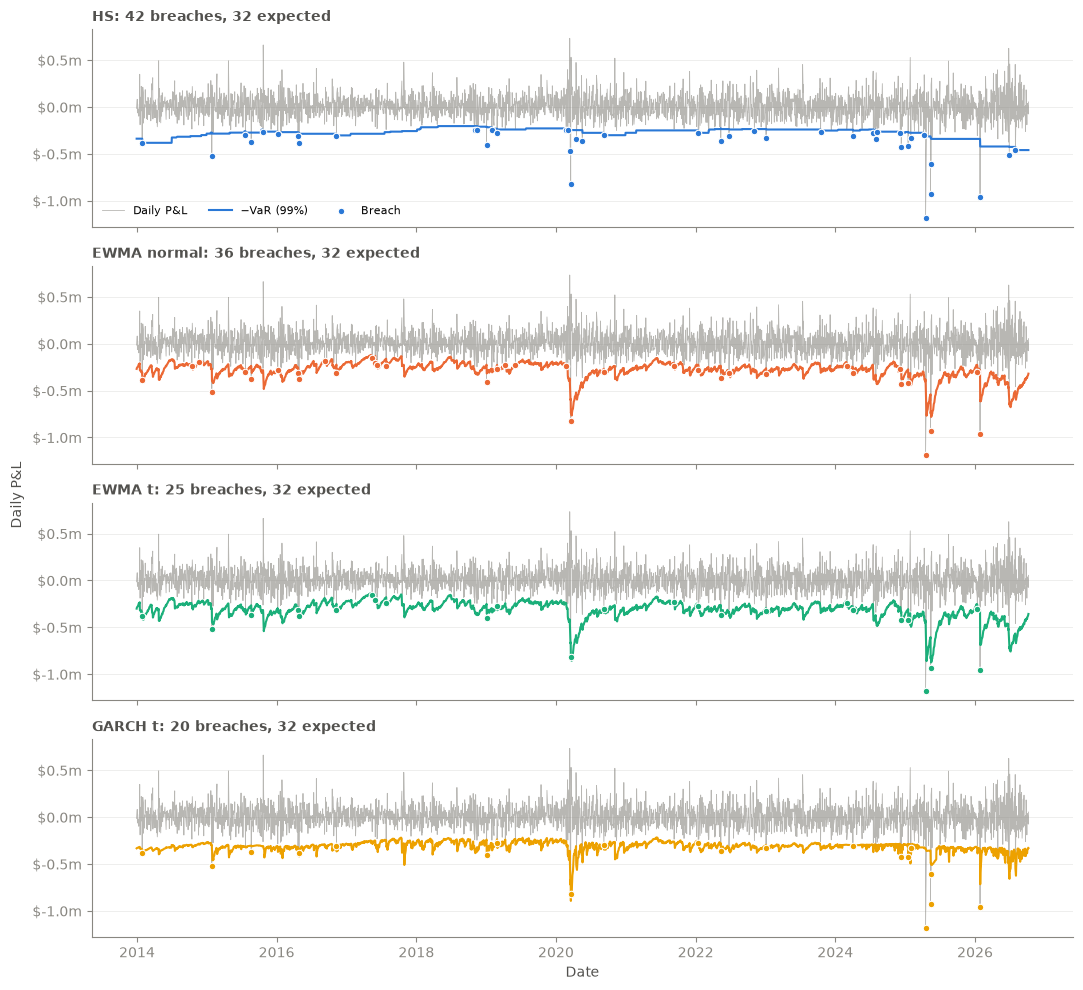

In [5]:
# reference palette, categorical slots 1-4, the same model colours as backtesting.ipynb
COLORS = {"HS": "#2a78d6", "EWMA normal": "#eb6834", "EWMA t": "#1baf7a", "GARCH t": "#eda100"}
MUTED, INK = "#898781", "#52514e"

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.titlecolor": INK,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
})


def dollars(y, _):
    return f"${y / 1e6:.1f}m"


v, book_pnl = var["book"], pnl["book"].loc[var["book"].index]

fig, axes = plt.subplots(len(COLORS), 1, figsize=(11, 10), sharex=True, sharey=True)
for ax, (name, color) in zip(axes, COLORS.items()):
    h = hits[("book", name)]
    ax.plot(book_pnl.index, book_pnl, color=MUTED, lw=0.6, alpha=0.6, label="Daily P&L")
    ax.plot(v.index, -v[name], color=color, lw=1.5, label="−VaR (99%)")
    ax.scatter(
        book_pnl.index[h], book_pnl[h], s=22, color=color,
        edgecolor="white", linewidth=0.8, zorder=3, label="Breach",
    )
    ax.set_title(f"{name}: {int(h.sum())} breaches, {ALPHA * len(h):.0f} expected", fontsize=10)
    ax.grid(axis="y", color=MUTED, alpha=0.2, lw=0.5)
    ax.yaxis.set_major_formatter(dollars)

axes[0].legend(loc="lower left", frameon=False, fontsize=8, ncols=3)
axes[-1].set_xlabel("Date")
fig.supylabel("Daily P&L", color=INK, fontsize=10)
fig.tight_layout()
plt.show()

## Diversification

The two desks are close to uncorrelated, so their losses rarely land on the same day. The book's VaR is therefore lower than the sum of the two desks' VaRs, and the gap is the diversification benefit. This uses the GARCH t model.

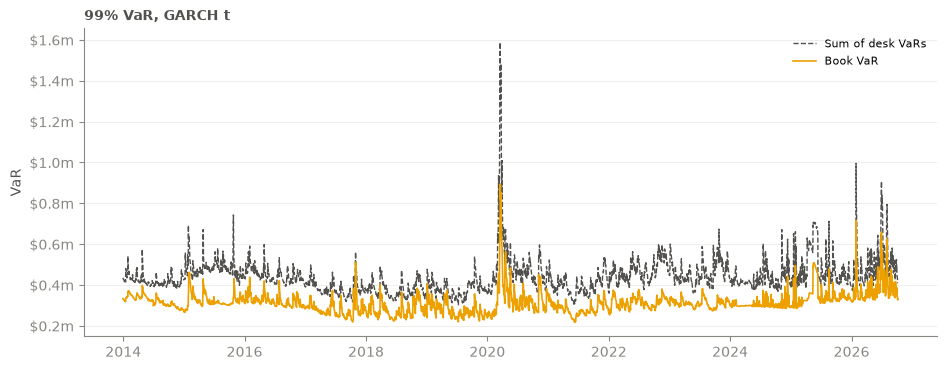

diversification benefit: mean 28%, range 8% to 58%


equity_ls    292.0
rates_fx     148.0
book         313.0
Name: mean VaR ($k), dtype: float64

In [6]:
MODEL = "GARCH t"
desk_sum = var["equity_ls"][MODEL] + var["rates_fx"][MODEL]
book_var = var["book"][MODEL]
both = desk_sum.index.intersection(book_var.index)
desk_sum, book_var = desk_sum.loc[both], book_var.loc[both]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(desk_sum.index, desk_sum, color=INK, lw=1, ls="--", label="Sum of desk VaRs")
ax.plot(book_var.index, book_var, color=COLORS[MODEL], lw=1.2, label="Book VaR")
ax.set_title(f"99% VaR, {MODEL}", fontsize=10)
ax.set_ylabel("VaR")
ax.yaxis.set_major_formatter(dollars)
ax.grid(axis="y", color=MUTED, alpha=0.2, lw=0.5)
ax.legend(frameon=False, fontsize=8)
plt.show()

benefit = 1 - book_var / desk_sum
print(f"diversification benefit: mean {benefit.mean():.0%}, range {benefit.min():.0%} to {benefit.max():.0%}")
pd.DataFrame({desk: var[desk][MODEL].loc[both] for desk in pnl.columns}).mean().div(1e3).round(0).rename("mean VaR ($k)")

## Book breaches per year

The dashed line is the expected count per year (about 2.5 at 99%).

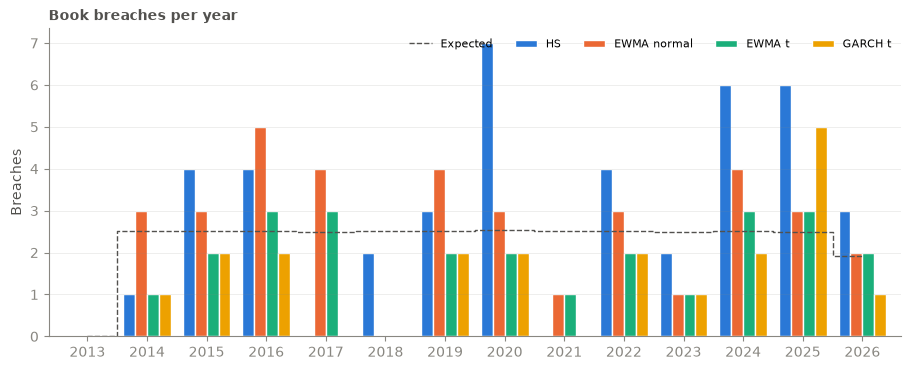

,HS,EWMA normal,EWMA t,GARCH t,days
Date,,,,,
2013,0,0,0,0,2
2014,1,3,1,1,252
2015,4,3,2,2,252
2016,4,5,3,2,252
2017,0,4,3,0,249
2018,2,0,0,0,251
2019,3,4,2,2,251
2020,7,3,2,2,253
2021,0,1,1,0,252


In [7]:
book_hits = pd.DataFrame({model: hits[("book", model)] for model in COLORS})
by_year = book_hits.groupby(lambda d: d.year).sum()
days_per_year = book_hits.groupby(lambda d: d.year).size()

ax = by_year.plot.bar(
    figsize=(11, 4), width=0.8, color=[COLORS[c] for c in by_year.columns],
    edgecolor="white", linewidth=1,
)
ax.step(
    range(len(days_per_year)), ALPHA * days_per_year, where="mid",
    color=INK, ls="--", lw=1, label="Expected",
)
ax.set_title("Book breaches per year", fontsize=10)
ax.set_xlabel("")
ax.set_ylabel("Breaches")
ax.grid(axis="y", color=MUTED, alpha=0.2, lw=0.5)
ax.legend(frameon=False, fontsize=8, ncols=5)
plt.xticks(rotation=0)
plt.show()

by_year.assign(days=days_per_year)

## Takeaways

These numbers are from the book at 99%, 2013-12-30 to 2026-10-07 (3,208 days). Rerun to refresh them.

- **Hedging reverses the SPY results.** On SPY every model had too many breaches. On the book, EWMA t passes all three tests on every series, and GARCH t is too conservative: 20 breaches against 32.1 expected, so Kupiec rejects it for having too few (p = 0.021).
- **The reason is the tail shape.** Dividing P&L by GARCH's volatility leaves a 1% quantile of −2.34 for the book and skew close to 0. SPY's was −2.95 with skew −0.70. Long-short positions cancel most of the market's crash asymmetry, so the book's tails sit between normal (−2.33) and the t with ν = 5 (−2.61), and fixing ν = 5 overstates the risk. Fitted ν varies a lot by desk: about 4 for equity_ls and 11 for rates_fx.
- **Book GARCH has little persistence.** On the latest window β is 0.57, against about 0.87 for SPY, so its VaR mostly sits at a long-run level with short spikes. Hedged P&L has less volatility clustering than the market.
- **HS clusters on rates_fx (Christoffersen p = 0.002).** Its almost-flat VaR is slow to react when rates volatility shifts, so breaches arrive in runs.
- **Diversification is worth 28% on average.** The two desks have a −0.10 correlation, so the book's GARCH VaR is on average 28% below the sum of the two desk VaRs (range 8-58%). Mean VaR is $292k for equity_ls and $148k for rates_fx, but only $313k for the book.
- **What to try:** take ν from each fit instead of fixing it at 5, which should fix GARCH t's conservatism on the book without hurting SPY much. A single ν for every series is the main weakness this notebook exposes.